# Task 1: Potential Problems in Linear Regression
This task explores common problems that may arise when fitting a linear regression model and use generative AI to create examples that illustrate these issues. 


1. Read section 3.3.3 Potential problems in the course textbook: An Introduction to Statistical Learning with applications in Python. The section covers six common issues when fitting a linear model.

2. Select 3 of the issues and for each:
- Write a short paragraph explaining what the problem is, why it matters, and how to detect it (and how to address it, if applicable)
- Write a question that came up while reading that you couldn’t answer from the text alone, and the answer you investigated

3. For each of the three issues, use a generative AI tool (such as ChatGPT, Claude, or Claude code) to write Python code that
- Generates synthetic data that clearly illustrates the issue
- Produces plots making the issue visually clear
- Where applicable, produces additional plots showing how the issue can be addressed
- Add a brief caption (2-3 sentences) describiing what the plots show, or integrate this explanation into your paragraph from step 2.

4. In a short paragraph (4–6 sentences), reflect on your use of generative AI in this task: which tool did you use, what prompts did you give it, and how many iterations did it take to get working code? Note any mistakes the AI made and how you identified and fixed them.


In [1]:
# Import necessary libraries for AI code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

np.random.seed(42)

## 1. Non-linearity of the response-predictor relationships

A linear regression model assumes that the relationship between predictor and response is linear. If the true relationship is non-linear, the linear regression model will not accurately capture the systems and patterns going on in the data. For example, if the true relationship is a curve, it will overpredict and underpredict in some parts of the data. This is an important issue because it can lead to incorrect conclusions and predictions about the data. Residual plots are a tool that can be used to identify non-linearity. If the residual plots show a curved pattern instead of random scatter, that is a sign that the linear model is not the right one for the data. This can be addressed by adding polynomial terms or a different, more flexible model. 

##### Question
If a linear model has a high R squared, can there still be a non-linearity issue? From my research, it seems that a high R squared can still occur, if the model captures the general direction of the response-predictor relationship. It is the residual plots that can reveal the systematic patterns going on behind the scenes. 

##### AI code:

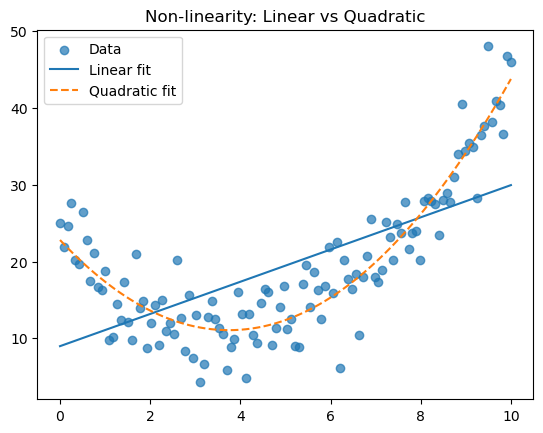

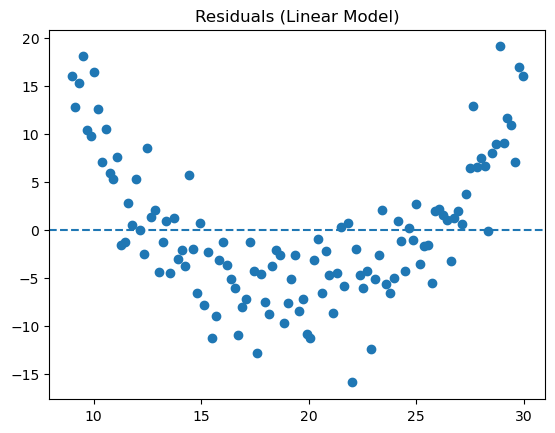

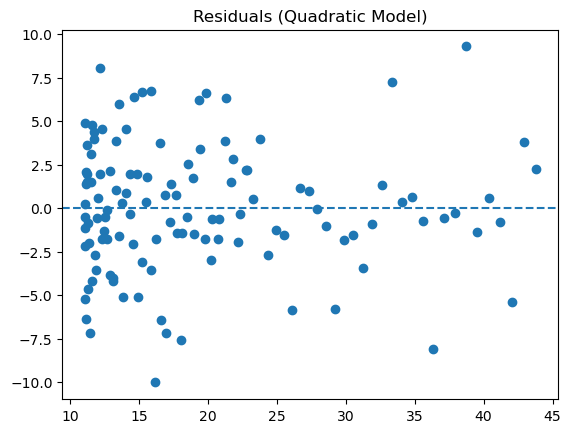

In [2]:
# Generate nonlinear data (quadratic relationship)
x = np.linspace(0, 10, 120)
noise = np.random.normal(0, 4, size=len(x))
y = 3 + 2*x + 0.8*(x - 5)**2 + noise  # nonlinear pattern

X = x.reshape(-1, 1)

# Fit linear model (misspecified)
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)
residuals_linear = y - y_pred_linear  # compute residuals

# Fit polynomial model (fix)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X, y)
y_pred_poly = poly_model.predict(X)
residuals_poly = y - y_pred_poly

# Plot data and model fits
plt.scatter(x, y, alpha=0.7, label="Data")
plt.plot(x, y_pred_linear, label="Linear fit")
plt.plot(x, y_pred_poly, linestyle="--", label="Quadratic fit")
plt.legend()
plt.title("Non-linearity: Linear vs Quadratic")
plt.show()

# Residual plot (linear model)
plt.scatter(y_pred_linear, residuals_linear)
plt.axhline(0, linestyle="--")
plt.title("Residuals (Linear Model)")
plt.show()

# Residual plot (after fix)
plt.scatter(y_pred_poly, residuals_poly)
plt.axhline(0, linestyle="--")
plt.title("Residuals (Quadratic Model)")
plt.show()

##### Caption
The first plot shows that the true relationship between X and Y is curved, so the straight-line model does not capture the pattern well. The residual plot for the linear model shows a curved pattern, which indicates non-linearity. After adding a quadratic term, the residuals appear more randomly scattered around zero, suggesting a better fit.


## 2. Non-constant variance of error terms

A linear regression model assumption is that the error terms have constant variance (homoscedasticity). However, it is possible that the spread of residuals changes across the values. This is called heteroskedasticity/ non-constant variance. When this is the case, standard errors, confidence intervals and other metrics become unreliable. The issue can be detected using residual plots, just like in the previous issue. If the residuals form a funnel shape, this is a sign of non-constant variance. A possible solution would be to transform the response variable using a concave function to shrink the larger responses. 

##### Question

If there is heteroskedasticity and I unknowingly proceeed with a linear regression model, would all the coefficient estimates be wrong? The answer I found was that they may still be correct in certain areas of the data. The model may, by chance, accurately estimate some of the relationships between predictor and response. But, other things like standard errors or p-values would be unreliable.

##### AI code:

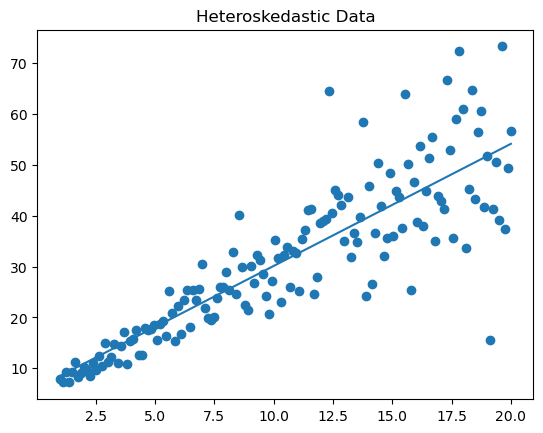

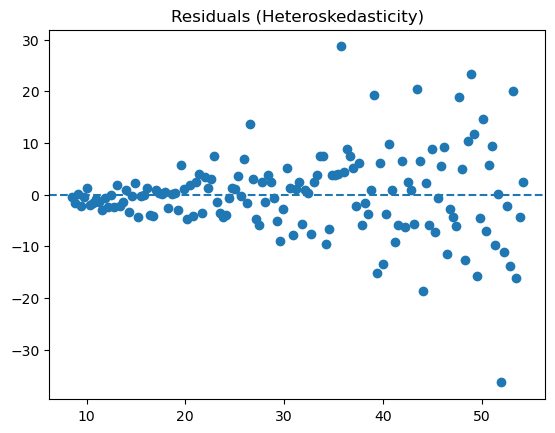

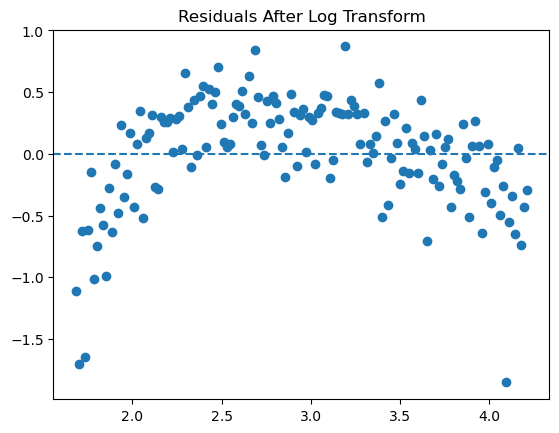

In [3]:
# Generate data with increasing variance
x = np.linspace(1, 20, 150)
noise = np.random.normal(0, 0.6 * x, size=len(x))  # variance increases with x
y = 5 + 2.5*x + noise

X = x.reshape(-1, 1)

# Fit linear model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

# Plot data (fan shape)
plt.scatter(x, y)
plt.plot(x, y_pred)
plt.title("Heteroskedastic Data")
plt.show()

# Residual plot (shows non-constant variance)
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.title("Residuals (Heteroskedasticity)")
plt.show()

# Apply log transform (attempt to fix)
y_log = np.log(y - y.min() + 1)

model_log = LinearRegression()
model_log.fit(X, y_log)
y_log_pred = model_log.predict(X)
residuals_log = y_log - y_log_pred

# Residual plot after transformation
plt.scatter(y_log_pred, residuals_log)
plt.axhline(0, linestyle="--")
plt.title("Residuals After Log Transform")
plt.show()

##### Caption
The scatterplot and residual plot show that the variability in Y increases as X increases, creating a funnel-shaped pattern. This violates the constant variance assumption of linear regression. After applying a log transformation to the response, the residual spread becomes more even, although transformation may not always fully solve the issue.

## 3. Collinearity

Collinearity occurs when two or more predictors are strongly correlated with one another. This makes it difficult to separate and interpret the individual effects of collinear variables on the response variable. This is an important issue because coefficient estimates would be incorrect/uncertain. this can be detected using correlation matrixes of the predictors. When the collinearity involves more than a pair of variables, variance inflation factor can help assess the correlation between the variables. To address collinearity, one of the problematic variables can be dropped from the regression altogether (if this does not significantly compromise the fit), or by combining the collinear variables into one predictor in the model. 

##### Question

How can I know if a problem variable can be safely dropped without significantly affecting the model fit? The answer I found is that I could compare model performance with and without the problem variable and compare the performance. It would also depend on what my goal is - inference or prediction. If my goal were inference, dropping the problem variable could significantly affect the coefficients and their interpretability.  


##### AI code:

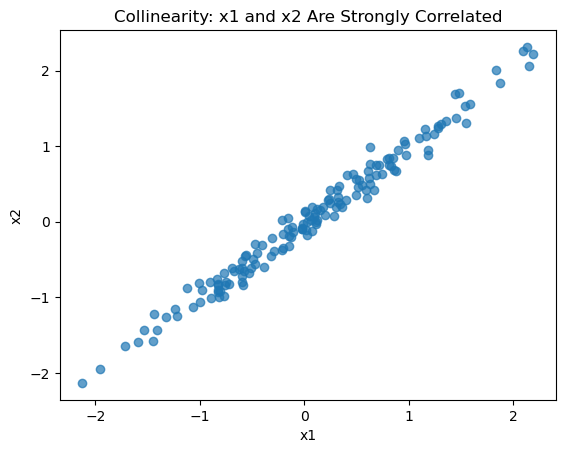

Coefficients with both predictors:
x1: 3.041051310050082
x2: 2.9665054699004627

Coefficient after dropping x2:
x1: 6.001511718369454
Model with both predictors
R²: 0.96425482583843
RMSE: 1.0245739680851629

Model after dropping x2
R²: 0.9597610789370601
RMSE: 1.087070654933285


,Model,R²,RMSE
0,Both predictors,0.964255,1.024574
1,Dropped x2,0.959761,1.087071


In [4]:
# Generate correlated predictors
n = 150
x1 = np.random.normal(0, 1, n)
x2 = x1 + np.random.normal(0, 0.12, n)  # x2 is highly correlated with x1
noise = np.random.normal(0, 1, n)

# Create response variable
y = 4 + 3*x1 + 3*x2 + noise

# Fit model with both predictors
X_both = np.column_stack((x1, x2))

model_both = LinearRegression()
model_both.fit(X_both, y)

# Fit simpler model after dropping x2
X_x1 = x1.reshape(-1, 1)

model_x1 = LinearRegression()
model_x1.fit(X_x1, y)

# Plot relationship between the two predictors
plt.scatter(x1, x2, alpha=0.7)
plt.title("Collinearity: x1 and x2 Are Strongly Correlated")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# Compare coefficients from both models
print("Coefficients with both predictors:")
print("x1:", model_both.coef_[0])
print("x2:", model_both.coef_[1])

print("\nCoefficient after dropping x2:")
print("x1:", model_x1.coef_[0])

# Generate predictions from both models
y_pred_both = model_both.predict(X_both)
y_pred_x1 = model_x1.predict(X_x1)

# Compare model fit using R²
r2_both = r2_score(y, y_pred_both)
r2_x1 = r2_score(y, y_pred_x1)

# Compare model fit using RMSE
rmse_both = np.sqrt(mean_squared_error(y, y_pred_both))
rmse_x1 = np.sqrt(mean_squared_error(y, y_pred_x1))

# Print model fit comparison
print("Model with both predictors")
print("R²:", r2_both)
print("RMSE:", rmse_both)

print("\nModel after dropping x2")
print("R²:", r2_x1)
print("RMSE:", rmse_x1)

# Create comparison table
comparison_table = pd.DataFrame({
    "Model": ["Both predictors", "Dropped x2"],
    "R²": [r2_both, r2_x1],
    "RMSE": [rmse_both, rmse_x1]
})

comparison_table

##### Caption
The results show that dropping x2 slightly reduces model performance, but not by much, indicating that x2 provides largely redundant information due to its strong correlation with x1. However, the coefficient for x1 changes substantially when x2 is removed, illustrating how collinearity affects the stability and interpretation of model coefficients. This is an excellent example of the tradeoffs that come with  dropping a collinear variable for prediction vs interpretation.

## Reflection

I used ChatGPT as the generative AI tool for this task. My prompt followed a structured, 3 step approach: first asking it to research and gather an understa ding of my 3 issues, then asking it to combine that knowledge with what I already written about the issue, then to consider potential solutions, and finally to generate synthetic data and Python code to illustrate both the problem and, where applicable, a fix. I prefer to give clearly laid out steps in my prompts to avoid unnecessarily long or overly extensive responses and to keep the output focused. This worked well for me. I was surprised that it only took one iteration to get working code, as all of the code chunks ran successfully on the first attempt without errors. The only adjustment I had to make was adding my own code cell at the beginning of the notebook to import the necessary libraries. Overall, this process showed that generative AI can be highly effective for quickly producing structured examples, and it was a very helpful learning experience to have AI visually illustrate the theoretical concepts from the textbook. I had not considered using AI in this way before, but it proved to be a great approach since it can be difficult to visualize what code output will look like when only reading about it/learning new things.